## Charts

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from datetime import datetime

today = datetime.today().strftime('%Y-%m-%d')



In [4]:
import os
import glob
import pandas as pd

# Define the directory containing the files
folder_path = "/Users/dougs/Library/CloudStorage/Box-Box/hsx_data/"

# Get a list of all CSV files in the folder
csv_files = glob.glob(os.path.join(folder_path, "hsx_daily_*.csv"))

# Ensure there are files before proceeding
if not csv_files:
    raise FileNotFoundError("No CSV files found in the directory.")

# Find the most recent file based on modification time
latest_file = max(csv_files, key=os.path.getmtime)

# Read the latest CSV file into a DataFrame
latest_file

'/Users/dougs/Library/CloudStorage/Box-Box/hsx_data/hsx_daily_2026-01-30_anticipation.csv'

In [5]:
import pandas as pd

hsx = hsx = pd.read_csv(latest_file)
#nz = pd.read_csv("newzoo.csv")
TVT = pd.read_csv("tvtime_release_cal.csv", skiprows=1)
TVT_NEW = pd.read_csv("TVT_NEW.csv", skiprows=1)
TVT_RET = pd.read_csv("TVT_RET.csv", skiprows=1)


In [6]:
TVT

,title,titleId,releaseDate,growth40,growth7,growth30,followers
0,Peaky Blinders: The Immortal Man,ea3a24e0-bad5-45d0-bc36-0c7d864b3455,2026-03-20,0.736134,0,0.736134,16037.330067
1,Scarpetta,464253,2026-03-11,1.589794,0,1.143404,15455.739088
2,Project Hail Mary,63e60b10-630b-4b01-b95a-93ff0bd89bfe,2026-03-18,0.299967,0,0.279934,13822.795467
3,The Madison,441735,2026-03-14,0.380934,0,0.342234,13577.166481
4,The Testaments,460241,2026-04-08,0.185715,0,0.245188,12555.471424
...,...,...,...,...,...,...,...
145,BTS THE COMEBACK LIVE | ARIRANG,88f52930-c83e-48b4-b1d5-8fd12ed0f729,2026-03-21,0.856414,0,0.861541,98.393686
146,Murder in the Building,c2ba9fea-0a3f-4680-b719-38cde0205f48,2026-03-11,54.548652,0,2.003437,98.211139
147,Kujima Utaeba Ie Hororo,449913,2026-04-09,0.154775,0,0.211622,96.310049
148,Born to Bowl,474918,2026-03-16,NaN,0,NaN,94.864266


In [7]:
from datetime import datetime, timedelta

pd.options.display.max_rows = 3000
today = datetime.today().date()
#today = datetime.strptime("2025-02-23", "%Y-%m-%d")  # Correct format
end_date = today + timedelta(days=365)
hsx.update_date = pd.to_datetime(hsx.update_date)
hsx.release_date = pd.to_datetime(hsx.release_date)

TVT.releaseDate = pd.to_datetime(TVT.releaseDate)
#TVT_NEW.releaseDate = pd.to_datetime(TVT_NEW.releaseDate)
#TVT_RET.releaseDate = pd.to_datetime(TVT_RET.releaseDate)


#today = '5/10/2023'
#hsx = hsx.query("update_date == '2025-10-06'", inplace=False)

In [8]:
hsx

,Unnamed: 0,hollywood_dollarschange_today,name,symbol,price,release_date,est_wknd_high,est_wknd_low,update_date,update_key,pull_date,diff_from_max,anticipation_score
0,Trade,H$0.05 (0%),Avengers: Secret Wars,AVNG6,471.48,2027-12-17,188.59,141.44,2026-01-30,AVNG62026-01-30,2026-01-30,686,1176.787268
1,Trade,H$0.60 (0%),Incredibles 3,NCRD3,348.35,2028-06-16,139.34,104.51,2026-01-30,NCRD32026-01-30,2026-01-30,868,1108.253969
2,Trade,H$0.55 (0%),Avengers: Doomsday,AVNG5,545.82,2026-12-18,218.33,163.75,2026-01-30,AVNG52026-01-30,2026-01-30,322,838.506711
3,Trade,-H$0.50 (-0%),Frozen III,FROZ3,309.53,2027-11-24,123.81,92.86,2026-01-30,FROZ32026-01-30,2026-01-30,663,749.236747
4,Trade,-H$0.11 (-0%),James Bond 26,JB26,161.67,2028-12-31,64.67,48.50,2026-01-30,JB262026-01-30,2026-01-30,1066,669.740654
5,Trade,H$0.27 (0%),A Minecraft Movie II,MINE2,307.26,2027-07-23,122.90,92.18,2026-01-30,MINE22026-01-30,2026-01-30,539,630.404049
6,Trade,-H$0.25 (-0%),The Batman: Part II,TBAT2,250.26,2027-10-01,100.10,75.08,2026-01-30,TBAT22026-01-30,2026-01-30,609,563.687702
7,Trade,H$0.50 (0%),The Super Mario Galaxy Movie,MARI2,498.18,2026-04-01,199.27,149.45,2026-01-30,MARI22026-01-30,2026-01-30,61,540.391994
8,Trade,-H$0.24 (-0%),Spider-Man: Brand New Day,SPID9,421.23,2026-07-31,168.49,126.37,2026-01-30,SPID92026-01-30,2026-01-30,182,536.918154
9,Trade,-H$0.24 (-0%),Man of Tomorrow,SPMOT,266.10,2027-07-09,106.44,79.83,2026-01-30,SPMOT2026-01-30,2026-01-30,525,535.859595


In [9]:
#dropped_col  = ['Unnamed: 0','symbol','pull_date','update_key','update_date']

In [10]:
upcoming = hsx.sort_values(by=['release_date','est_wknd_high','name'] , ascending=[True, False, True])
upcoming.columns

Index(['Unnamed: 0', 'hollywood_dollarschange_today', 'name', 'symbol',
       'price', 'release_date', 'est_wknd_high', 'est_wknd_low', 'update_date',
       'update_key', 'pull_date', 'diff_from_max', 'anticipation_score'],
      dtype='object')

In [11]:
col_list = ['name','release_date','price','est_wknd_high', 'est_wknd_low']

In [12]:
upcoming[col_list]

,name,release_date,price,est_wknd_high,est_wknd_low
98,Send Help,2026-01-30,42.83,17.13,12.85
133,Iron Lung,2026-01-30,17.42,6.97,5.23
137,Shelter,2026-01-30,16.92,6.77,5.08
173,Melania,2026-01-30,4.16,1.66,1.25
196,Infinite Icon: A Visual Memoir,2026-01-30,1.42,0.57,0.43
213,Islands,2026-01-30,0.20,0.08,0.06
141,The Strangers: Chapter 3,2026-02-06,13.43,5.37,4.03
150,Solo Mio,2026-02-06,10.46,4.18,3.14
158,The Moment,2026-02-06,9.17,3.67,2.75
166,Whistle,2026-02-06,6.38,2.55,1.91


In [13]:
upcoming['month'] = upcoming.release_date.dt.month
upcoming['year'] = upcoming.release_date.dt.year


In [14]:
upcoming

,Unnamed: 0,hollywood_dollarschange_today,name,symbol,price,release_date,est_wknd_high,est_wknd_low,update_date,update_key,pull_date,diff_from_max,anticipation_score,month,year
98,NaN,H$1.10 (3%),Send Help,SENDH,42.83,2026-01-30,17.13,12.85,2026-01-30,SENDH2026-01-30,2026-01-30,0,42.830000,1,2026
133,NaN,H$0.29 (2%),Iron Lung,IRONL,17.42,2026-01-30,6.97,5.23,2026-01-30,IRONL2026-01-30,2026-01-30,0,17.420000,1,2026
137,NaN,H$0.19 (1%),Shelter,SELTR,16.92,2026-01-30,6.77,5.08,2026-01-30,SELTR2026-01-30,2026-01-30,0,16.920000,1,2026
173,NaN,H$0.20 (5%),Melania,MLNIA,4.16,2026-01-30,1.66,1.25,2026-01-30,MLNIA2026-01-30,2026-01-30,0,4.160000,1,2026
196,NaN,-H$0.04 (-3%),Infinite Icon: A Visual Memoir,INFIC,1.42,2026-01-30,0.57,0.43,2026-01-30,INFIC2026-01-30,2026-01-30,0,1.420000,1,2026
213,NaN,H$0.01 (5%),Islands,ISLNS,0.20,2026-01-30,0.08,0.06,2026-01-30,ISLNS2026-01-30,2026-01-30,0,0.200000,1,2026
141,Trade,H$0.00 (0%),The Strangers: Chapter 3,STRN5,13.43,2026-02-06,5.37,4.03,2026-01-30,STRN52026-01-30,2026-01-30,7,13.555933,2,2026
150,Trade,-H$0.66 (-6%),Solo Mio,SOLOM,10.46,2026-02-06,4.18,3.14,2026-01-30,SOLOM2026-01-30,2026-01-30,7,10.558084,2,2026
158,Trade,-H$0.13 (-1%),The Moment,MOMNT,9.17,2026-02-06,3.67,2.75,2026-01-30,MOMNT2026-01-30,2026-01-30,7,9.255987,2,2026
166,Trade,H$0.07 (1%),Whistle,WHIST,6.38,2026-02-06,2.55,1.91,2026-01-30,WHIST2026-01-30,2026-01-30,7,6.439825,2,2026


In [15]:
price_volume = upcoming[col_list + ['month']].groupby('release_date')['price'].count()
price_volume = price_volume.reset_index()

<Axes: >

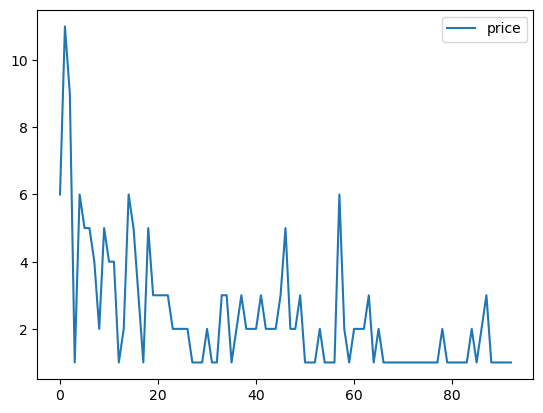

In [16]:
import seaborn as sns

sns.lineplot(price_volume)

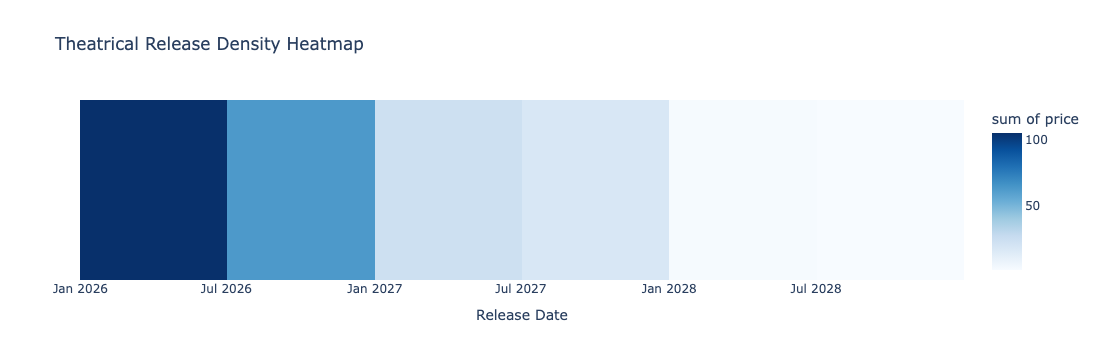

In [17]:
import pandas as pd
import plotly.express as px

# Create heatmap
fig = px.density_heatmap(
    price_volume, x="release_date", y=[1]*len(price_volume), z="price",
    color_continuous_scale="Blues", title="Theatrical Release Density Heatmap"
)

fig.update_layout(
    xaxis_title="Release Date",
    yaxis_title="",
    yaxis=dict(showticklabels=False)
)


fig.show()

In [18]:
price_volume_TVT = TVT.groupby('releaseDate')['followers'].count().reset_index()


In [19]:
price_volume_TVT

,releaseDate,followers
0,2026-03-10,2
1,2026-03-11,7
2,2026-03-13,12
3,2026-03-14,4
4,2026-03-15,2
5,2026-03-16,3
6,2026-03-17,1
7,2026-03-18,7
8,2026-03-19,1
9,2026-03-20,7


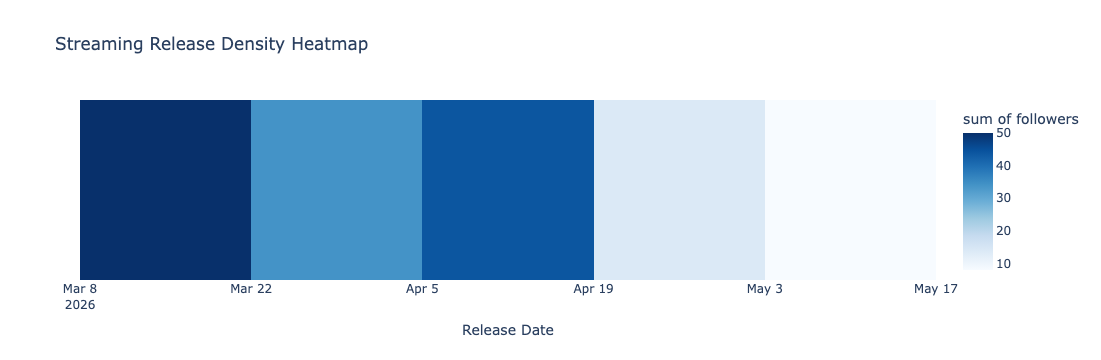

In [20]:
import pandas as pd
import plotly.express as px

# Create heatmap
fig = px.density_heatmap(
    price_volume_TVT, x="releaseDate", y=[1]*len(price_volume_TVT), z="followers",
    color_continuous_scale="Blues", title="Streaming Release Density Heatmap"
)

fig.update_layout(
    xaxis_title="Release Date",
    yaxis_title="",
    yaxis=dict(showticklabels=False)
)


fig.show()

## Google Calendar


In [22]:
print(hsx.columns)
#print(nz.columns)
print(TVT.columns)

Index(['Unnamed: 0', 'hollywood_dollarschange_today', 'name', 'symbol',
       'price', 'release_date', 'est_wknd_high', 'est_wknd_low', 'update_date',
       'update_key', 'pull_date', 'diff_from_max', 'anticipation_score'],
      dtype='object')
Index(['title', 'titleId', 'releaseDate', 'growth40', 'growth7', 'growth30',
       'followers'],
      dtype='object')


In [23]:
TVT

,title,titleId,releaseDate,growth40,growth7,growth30,followers
0,Peaky Blinders: The Immortal Man,ea3a24e0-bad5-45d0-bc36-0c7d864b3455,2026-03-20,0.736134,0,0.736134,16037.330067
1,Scarpetta,464253,2026-03-11,1.589794,0,1.143404,15455.739088
2,Project Hail Mary,63e60b10-630b-4b01-b95a-93ff0bd89bfe,2026-03-18,0.299967,0,0.279934,13822.795467
3,The Madison,441735,2026-03-14,0.380934,0,0.342234,13577.166481
4,The Testaments,460241,2026-04-08,0.185715,0,0.245188,12555.471424
5,The Devil Wears Prada 2,a4b14e7e-ceac-4a46-bac2-da5d0da275a6,2026-04-29,0.000000,0,0.130925,10127.984792
6,Imperfect Women,448179,2026-03-18,1.284525,0,1.112237,9106.962955
7,Star Wars: Maul - Shadow Lord,462715,2026-04-06,0.048828,0,0.133020,9013.802569
8,The Super Mario Galaxy Movie,2b688d44-6c1c-44f2-993c-f46111e59b84,2026-04-01,0.059224,0,0.123311,8948.379224
9,Witch Hat Atelier,418666,2026-04-06,0.066647,0,0.234174,7999.756810


In [24]:
TVT = TVT.sort_values(by="followers", ascending=False)
TVT = TVT

In [25]:
TVT

,title,titleId,releaseDate,growth40,growth7,growth30,followers
0,Peaky Blinders: The Immortal Man,ea3a24e0-bad5-45d0-bc36-0c7d864b3455,2026-03-20,0.736134,0,0.736134,16037.330067
1,Scarpetta,464253,2026-03-11,1.589794,0,1.143404,15455.739088
2,Project Hail Mary,63e60b10-630b-4b01-b95a-93ff0bd89bfe,2026-03-18,0.299967,0,0.279934,13822.795467
3,The Madison,441735,2026-03-14,0.380934,0,0.342234,13577.166481
4,The Testaments,460241,2026-04-08,0.185715,0,0.245188,12555.471424
5,The Devil Wears Prada 2,a4b14e7e-ceac-4a46-bac2-da5d0da275a6,2026-04-29,0.000000,0,0.130925,10127.984792
6,Imperfect Women,448179,2026-03-18,1.284525,0,1.112237,9106.962955
7,Star Wars: Maul - Shadow Lord,462715,2026-04-06,0.048828,0,0.133020,9013.802569
8,The Super Mario Galaxy Movie,2b688d44-6c1c-44f2-993c-f46111e59b84,2026-04-01,0.059224,0,0.123311,8948.379224
9,Witch Hat Atelier,418666,2026-04-06,0.066647,0,0.234174,7999.756810


In [26]:
hsx = hsx[['name', 'release_date', 'price']]

#hsx['studio'] = "theatrical"
hsx['platform'] = "hsx"
hsx['new_returing'] = "new"

#nz = nz[['Game', 'Initial Release Date', 'followers', 'Publisher']]
#nz['platform'] = "newzoo"
#nz['new_returing'] = "new"

TVT = TVT[['title', 'releaseDate', 'followers']]
TVT['platform'] = "TVT"
TVT['new_returing'] = "new"

#TVT_NEW = TVT_NEW[['show', 'releaseDate', 'followers', 'network']]
#TVT_NEW['platform'] = "TVT"
#TVT_NEW['new_returing'] = "new"

#TVT_RET = TVT_RET[['show', 'releaseDate', 'followers', 'network']]
#TVT_RET['platform'] = "TVT"
#TVT_RET['new_returing'] = "returning"

In [27]:
hsx

,name,release_date,price,platform,new_returing
0,Avengers: Secret Wars,2027-12-17,471.48,hsx,new
1,Incredibles 3,2028-06-16,348.35,hsx,new
2,Avengers: Doomsday,2026-12-18,545.82,hsx,new
3,Frozen III,2027-11-24,309.53,hsx,new
4,James Bond 26,2028-12-31,161.67,hsx,new
5,A Minecraft Movie II,2027-07-23,307.26,hsx,new
6,The Batman: Part II,2027-10-01,250.26,hsx,new
7,The Super Mario Galaxy Movie,2026-04-01,498.18,hsx,new
8,Spider-Man: Brand New Day,2026-07-31,421.23,hsx,new
9,Man of Tomorrow,2027-07-09,266.10,hsx,new


In [28]:

# New column names
new_names = ['title', 'release_date', 'anticipation', 'studio',  'new_returning' ]

In [29]:
hsx.rename(columns=dict(zip(hsx.columns[:6], new_names)), inplace=True)
#nz.rename(columns=dict(zip(nz.columns[:6], new_names)), inplace=True)
TVT.rename(columns=dict(zip(TVT.columns[:6], new_names)), inplace=True)
#TVT_NEW.rename(columns=dict(zip(TVT_NEW.columns[:6], new_names)), inplace=True)
#TVT_RET.rename(columns=dict(zip(TVT_RET.columns[:6], new_names)), inplace=True)


In [30]:
TVT

,title,release_date,anticipation,studio,new_returning
0,Peaky Blinders: The Immortal Man,2026-03-20,16037.330067,TVT,new
1,Scarpetta,2026-03-11,15455.739088,TVT,new
2,Project Hail Mary,2026-03-18,13822.795467,TVT,new
3,The Madison,2026-03-14,13577.166481,TVT,new
4,The Testaments,2026-04-08,12555.471424,TVT,new
5,The Devil Wears Prada 2,2026-04-29,10127.984792,TVT,new
6,Imperfect Women,2026-03-18,9106.962955,TVT,new
7,Star Wars: Maul - Shadow Lord,2026-04-06,9013.802569,TVT,new
8,The Super Mario Galaxy Movie,2026-04-01,8948.379224,TVT,new
9,Witch Hat Atelier,2026-04-06,7999.756810,TVT,new


In [31]:
hsx.sort_values(by='release_date')

,title,release_date,anticipation,studio,new_returning
196,Infinite Icon: A Visual Memoir,2026-01-30,1.42,hsx,new
133,Iron Lung,2026-01-30,17.42,hsx,new
213,Islands,2026-01-30,0.20,hsx,new
173,Melania,2026-01-30,4.16,hsx,new
98,Send Help,2026-01-30,42.83,hsx,new
137,Shelter,2026-01-30,16.92,hsx,new
181,Pillion,2026-02-06,2.64,hsx,new
200,Kokuho,2026-02-06,0.95,hsx,new
203,Jimpa,2026-02-06,0.88,hsx,new
175,Dracula,2026-02-06,4.03,hsx,new


In [32]:
final_df = pd.concat([hsx,TVT])

In [33]:
final_df['release_date'] = pd.to_datetime(final_df['release_date'])

In [34]:
final_df.sort_values(by='release_date')

,title,release_date,anticipation,studio,new_returning
137,Shelter,2026-01-30,16.920000,hsx,new
173,Melania,2026-01-30,4.160000,hsx,new
196,Infinite Icon: A Visual Memoir,2026-01-30,1.420000,hsx,new
133,Iron Lung,2026-01-30,17.420000,hsx,new
98,Send Help,2026-01-30,42.830000,hsx,new
213,Islands,2026-01-30,0.200000,hsx,new
203,Jimpa,2026-02-06,0.880000,hsx,new
212,The President's Cake,2026-02-06,0.210000,hsx,new
150,Solo Mio,2026-02-06,10.460000,hsx,new
158,The Moment,2026-02-06,9.170000,hsx,new


In [35]:
final_df['release_date'] = pd.to_datetime(final_df['release_date'])

In [36]:
final_df = final_df.fillna("NA")

In [37]:
len(final_df)

365

In [38]:
final_df.to_clipboard()

In [39]:
final_df['title'] = final_df['title'].str.upper()


In [40]:
grouped_df = final_df.groupby("studio")

In [41]:
HSX_final = grouped_df.get_group("hsx")
TVT_final = grouped_df.get_group("TVT")
#NZ_final = grouped_df.get_group("newzoo")

In [42]:
TVT_final.sort_values("release_date")

,title,release_date,anticipation,studio,new_returning
136,LE LIBERE DONNE,2026-03-10,120.224841,TVT,new
130,FUKUSHIMA: A NUCLEAR NIGHTMARE,2026-03-10,127.975394,TVT,new
1,SCARPETTA,2026-03-11,15455.739088,TVT,new
103,LOUIS THEROUX: INSIDE THE MANOSPHERE,2026-03-11,216.014684,TVT,new
146,MURDER IN THE BUILDING,2026-03-11,98.211139,TVT,new
76,NA,2026-03-11,437.454434,TVT,new
77,A WOMAN OF SUBSTANCE (2026),2026-03-11,428.818961,TVT,new
79,AGE OF ATTRACTION,2026-03-11,378.801874,TVT,new
85,E! DIRTY ROTTEN SCANDALS: AMERICA'S NEXT TOP M...,2026-03-11,315.616515,TVT,new
49,PHANTOM LAWYER,2026-03-13,946.494787,TVT,new


In [43]:
from icalendar import Calendar, Event
from datetime import datetime, timezone


# Create Calendar
cal = Calendar()
cal.add('prodid', '-//My Calendar//')
cal.add('version', '2.0')

# Add events for each movie
for _, row in HSX_final.iterrows():
    event = Event()
    event.add('summary', f"{row['title']} ({row['studio']})")  # Event title
    event.add('dtstart', row["release_date"].date())  # Use only the date
    event.add('dtstamp', datetime.utcnow())  # Current timestamp
    event.add('description', f"Anticipation Score: {row['anticipation']}")

    cal.add_component(event)

# Save to ICS file
ics_filename = "HSX_calendar.ics"
with open(ics_filename, "wb") as f:
    f.write(cal.to_ical())

print(f"ICS file generated: {ics_filename}")

ICS file generated: HSX_calendar.ics


In [44]:
from icalendar import Calendar, Event
from datetime import datetime, timezone


# Create Calendar
cal = Calendar()
cal.add('prodid', '-//My Calendar//')
cal.add('version', '2.0')

# Add events for each movie
for _, row in TVT_final.iterrows():
    event = Event()
    event.add('summary', f"{row['title']} ({row['studio']})")  # Event title
    event.add('dtstart', row["release_date"].date())  # Use only the date
    event.add('dtstamp', datetime.utcnow())  # Current timestamp
    event.add('description', f"Anticipation Score: {row['anticipation']}")

    cal.add_component(event)

# Save to ICS file
ics_filename = "TVT_calendar.ics"
with open(ics_filename, "wb") as f:
    f.write(cal.to_ical())

print(f"ICS file generated: {ics_filename}")

ICS file generated: TVT_calendar.ics
